# 1
- pure comp: molecular
- kij: molecular
- melting: molecular

In [1]:
using Pkg, Revise
using Clapeyron, PyCall
import PyPlot; const plt = PyPlot
import DataFrames

In [18]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter1 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8495,2.3270,216.9600,2,2
ethanol,46.07,2.3827,3.1771,198.24,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter1 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_held,0.054
water,glycine_held,-0.0612
water,ethanol,-0.0382
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter1 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
water,H,water,e,2425.67,0.045
glycine_held,H,glycine_held,e,2598.06,0.0393 
ethanol,H,glycine_held,e,2625.73,0.034406
ethanol,e,glycine_held,H,2625.73,0.034406
water,H,glycine_held,e,2511.865,0.041515
water,e,glycine_held,H,2511.865,0.041515
water,e,ethanol,H,2539.535,0.037949
water,H,ethanol,e,2539.535,0.037949
"""
components = ["water", "ethanol", "glycine_held"]
model1 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter1, unlike_parameter1, assoc_parameter1])

println(model1.fluid.params.epsilon.values)
println(model1.fluid.params.sigma.values)
println("======================")
println(model1.fluid.params.epsilon_assoc.values)
println(model1.fluid.params.bondvol.values)
println("kij = ", (1  - ((model1.fluid.params.epsilon.values[2])/(sqrt(model1.fluid.params.epsilon.values[1] * model1.fluid.params.epsilon.values[4])))))
println("Hfus = ", model1.solid.params.Hfus[3])
println("Tm = ", model1.solid.params.Tm[3])

[353.94 275.0055713656837 294.07079841359604; 275.0055713656837 198.24 196.18988698545704; 294.07079841359604 196.18988698545704 216.96]
[2.8014570000000003e-10 2.9892785e-10 2.5642285e-10; 2.9892785e-10 3.1771e-10 2.75205e-10; 2.5642285e-10 2.75205e-10 2.327e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2539.535, 2539.535, 2511.865, 2511.865, 2653.4, 2625.73, 2625.73, 2598.06]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.037949, 0.037949, 0.041515, 0.041515, 0.032384, 0.034406, 0.034406, 0.0393]
kij = 0.1185332742259072
Hfus = 17536.72
Tm = 714.3



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Fraksi_Ethanol  Fraksi_Solute 
     │ Float64         Float64       
─────┼───────────────────────────────
   1 │      0.0        NaN
   2 │      0.010101     0.081113
   3 │      0.020202     0.0775137
   4 │      0.030303     0.0738879
   5 │      0.040404     0.0702597
   6 │      0.0505051    0.066653
   7 │      0.0606061    0.0630912
   8 │      0.0707071    0.0595964
   9 │      0.0808081    0.0561889
  10 │      0.0909091    0.0528866
  11 │      0.10101      0.0497044
  12 │      0.111111     0.0466542
  13 │      0.121212     0.0437448
  14 │      0.131313     0.0409819
  15 │      0.141414     0.0383684
  16 │      0.151515     0.0359044
  17 │      0.161616     0.0335884
  18 │      0.171717     0.0314167
  19 │      0.181818     0.0293844
  20 │      0.191919     0.0274859
  21 │      0.20202      0.0257145
  22 │      0.212121     0.0240636
  23 │      0.222222     0.022526
  24 │      0.232323     0.0210948
  25 │  

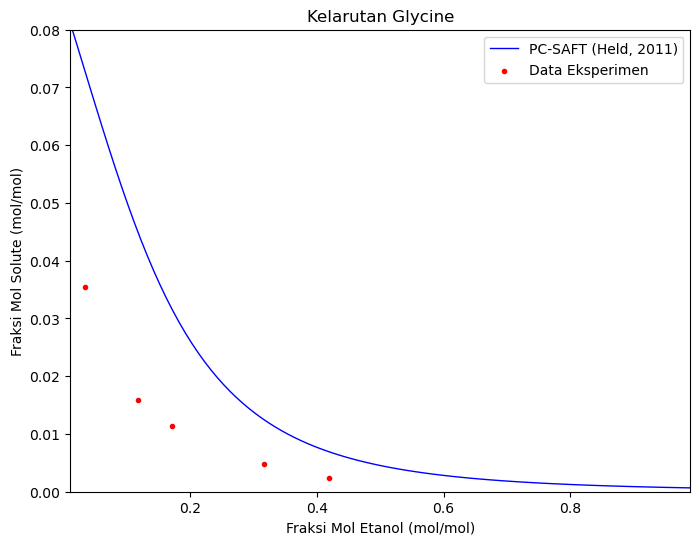

In [34]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_air_etanol.csv", DataFrame)

function plot_x(df)
    T = 298.15
    p = 101325
    x_ethanol = LinRange(0.,1.,100)
    
    s = zeros(length(x_ethanol))
    
    for i in 1:length(x_ethanol)
        s[i] = sle_solubility(model1, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_held"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Ethanol = x_ethanol,
        Fraksi_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_ethanol, s, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.x_ethanol, df.out_s, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.01, 0.99)
    plt.ylim(0., 0.08)
    
    plt.legend(loc="upper right")
    plt.savefig("1_plot_T_glycine_air_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_x(df_eksperimen)

In [16]:
using CSV, DataFrames, Printf

function solubility_gclow(model::EoSModel, x_ethanol::Float64)
    T = 298.15
    p = 101325
    x2 = sle_solubility(model, p, T, [1-x_ethanol,x_ethanol,0.]; solute=["glycine_gclow"])[3]
    return x2
end

function solubility_gcmid(model::EoSModel, x_ethanol::Float64)
    T = 298.15
    p = 101325
    x2 = sle_solubility(model, p, T, [1-x_ethanol,x_ethanol,0.]; solute=["glycine_gcmid"])[3]
    return x2
end

function solubility_gcup(model::EoSModel, x_ethanol::Float64)
    T = 298.15
    p = 101325
    x2 = sle_solubility(model, p, T, [1-x_ethanol,x_ethanol,0.]; solute=["glycine_gcup"])[3]
    return x2
end

function solubility_held(model::EoSModel, x_ethanol::Float64)
    T = 298.15
    p = 101325
    x2 = sle_solubility(model, p, T, [1-x_ethanol,x_ethanol,0.]; solute=["glycine_held"])[3]
    return x2
end

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [19]:
aard_p   = calculate_AAD(model1, "sol_glycine_air_etanol.csv", solubility_held)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.072865      105.8319
0.1168      0.015900      0.044995      182.9873
0.1706      0.011300      0.031644      180.0320
0.3164      0.004800      0.012453      159.4337
0.4186      0.002400      0.006932      188.8168
AARD = 163.4203%


163.42033322778937

# 2
- pure comp: GC
- kij: GC
- melting: GC

In [4]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter2 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
ethanol,46.07,2.3827,3.1771,198.24,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter2 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_gclow,0.113903
ethanol,glycine_gcmid,0.113903
ethanol,glycine_gcup,0.113903
water,glycine_gclow,0.0000296035176
water,glycine_gcmid,0.0000296035176
water,glycine_gcup,0.0000296035176
water,ethanol,0.117078
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter2 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
ethanol,H,glycine_gclow,e,2832.759,0.088581
ethanol,e,glycine_gclow,H,2832.759,0.088581
ethanol,H,glycine_gcmid,e,2832.759,0.088581
ethanol,e,glycine_gcmid,H,2832.759,0.088581
ethanol,H,glycine_gcup,e,2832.759,0.088581
ethanol,e,glycine_gcup,H,2832.759,0.088581
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
water,e,ethanol,H,2539.535,0.037949
water,H,ethanol,e,2539.535,0.037949
"""
components_low = ["water", "ethanol", "glycine_gclow"]
components_mid = ["water", "ethanol", "glycine_gcmid"]
components_up = ["water", "ethanol", "glycine_gcup"]

model2_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])


println("low bound")
println("Hfus = ", model2_low.solid.params.Hfus[2])
println("Tm = ", model2_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model2_mid.solid.params.Hfus[2])
println("Tm = ", model2_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model2_up.solid.params.Hfus[2])
println("Tm = ", model2_up.solid.params.Tm[2])

low bound
Hfus = 4969.0
Tm = 158.7
mid bound
Hfus = 4969.0
Tm = 158.7
up bound
Hfus = 4969.0
Tm = 158.7



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Fraksi_Ethanol  Fraksi_Solute_Low  Fraksi_Solute_Mid  Fraksi_Solute_Up 
     │ Float64         Float64            Float64            Float64          
─────┼────────────────────────────────────────────────────────────────────────
   1 │      0.0            NaN                NaN               NaN
   2 │      0.0416667        0.0373355          0.00797328        0.00199135
   3 │      0.0833333        0.0325824          0.00762989        0.00194417
   4 │      0.125            0.0259731          0.00652739        0.00169347
   5 │      0.166667         0.0197287          0.00522054        0.00137346
   6 │      0.208333         0.0146125          0.00401223        0.00106647
   7 │      0.25             0.0106992          0.00301586        0.00080762
   8 │      0.291667         0.00781064         0.00224307        0.000603907
   9 │      0.333333         0.00571634         0.00166358        0.000449635
  10 │      0.375            

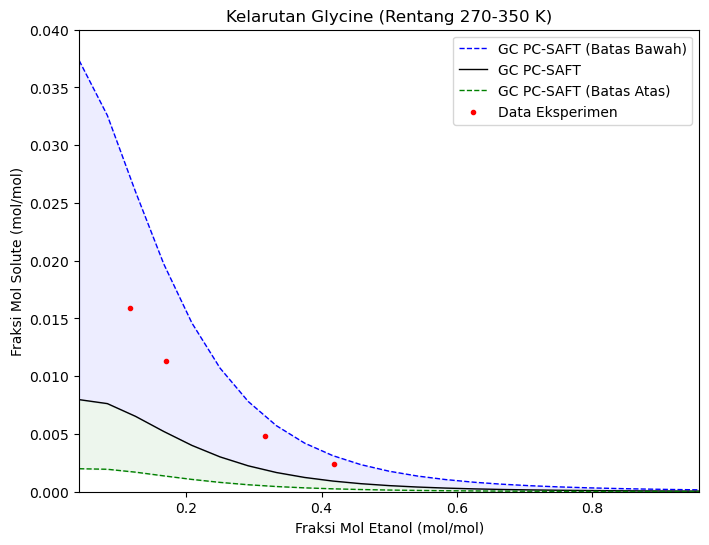

In [54]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_air_etanol.csv", DataFrame)

function plot_T(df)
    T = 298.15
    p = 101325
    x_ethanol = LinRange(0.,1.,25)
    
    s_low = zeros(length(x_ethanol))
    s_mid = zeros(length(x_ethanol))
    s_up = zeros(length(x_ethanol))

    
    for i in 1:length(x_ethanol)
        s_low[i] = sle_solubility(model2_low, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gclow"])[3]
        s_mid[i] = sle_solubility(model2_mid, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gcmid"])[3]
        s_up[i]  = sle_solubility(model2_up, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gcup"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Ethanol = x_ethanol,
        Fraksi_Solute_Low = s_low,
        Fraksi_Solute_Mid = s_mid,
        Fraksi_Solute_Up = s_up,)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_ethanol, s_low, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(x_ethanol, s_mid, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(x_ethanol, s_up, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_between(x_ethanol, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_between(x_ethanol, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.x_ethanol, df.out_s, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.0416667, 0.958333)
    plt.ylim(0.0, 0.04)
    
    plt.legend(loc="upper right")
    plt.savefig("2_plot_T_glycine_air_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)

In [20]:
aard_p   = calculate_AAD(model2_low, "sol_glycine_air_etanol.csv", solubility_gclow)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.037712      6.5302  
0.1168      0.015900      0.027287      71.6149 
0.1706      0.011300      0.019189      69.8140 
0.3164      0.004800      0.006484      35.0814 
0.4186      0.002400      0.003082      28.4278 
AARD = 42.2937%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


42.29369674578013

In [22]:
aard_p   = calculate_AAD(model2_mid, "sol_glycine_air_etanol.csv", solubility_gcmid)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.007887      77.7192 
0.1168      0.015900      0.006774      57.3958 
0.1706      0.011300      0.005098      54.8808 
0.3164      0.004800      0.001878      60.8789 
0.4186      0.002400      0.000912      61.9958 
AARD = 62.5741%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


62.574095871612585

In [23]:
aard_p   = calculate_AAD(model2_up, "sol_glycine_air_etanol.csv", solubility_gcup)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.001963      94.4561 
0.1168      0.015900      0.001752      88.9824 
0.1706      0.011300      0.001343      88.1163 
0.3164      0.004800      0.000507      89.4413 
0.4186      0.002400      0.000248      89.6769 
AARD = 90.1346%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


90.1346036565248

# 3
- pure comp: GC
- kij: GC
- melting: molecular

In [24]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter3 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8492,2.2140,238.6085,2,2 
ethanol,46.07,2.3827,3.1771,198.24,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter3 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_held,0.113903
water,glycine_held,0.0000296035176
water,ethanol,0.117078
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter3 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
water,H,water,e,2425.67,0.045
glycine_held,H,glycine_held,e,3012.118,0.267058
ethanol,H,glycine_held,e,2832.759,0.088581
ethanol,e,glycine_held,H,2832.759,0.088581
water,H,glycine_held,e,2718.894,0.107377
water,e,glycine_held,H,2718.894,0.107377
water,e,ethanol,H,2539.535,0.037949
water,H,ethanol,e,2539.535,0.037949
"""
components = ["water", "ethanol", "glycine_held"]
model3 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter3, unlike_parameter3, assoc_parameter3])

println(model3.fluid.params.epsilon.values)
println(model3.fluid.params.sigma.values)
println("======================")
println(model3.fluid.params.epsilon_assoc.values)
println(model3.fluid.params.bondvol.values)
println("kij = ", (1  - ((model3.fluid.params.epsilon.values[2])/(sqrt(model3.fluid.params.epsilon.values[1] * model3.fluid.params.epsilon.values[4])))))
println("Hfus = ", model3.solid.params.Hfus[2])
println("Tm = ", model3.solid.params.Tm[2])

[353.94 233.87446453605486 290.59953948138354; 233.87446453605486 198.24 192.71692880569157; 290.59953948138354 192.71692880569157 238.6085]
[2.8014570000000003e-10 2.9892785e-10 2.5077285000000003e-10; 2.9892785e-10 3.1771e-10 2.69555e-10; 2.5077285000000003e-10 2.69555e-10 2.214e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2539.535, 2539.535, 2718.894, 2718.894, 2653.4, 2832.759, 2832.759, 3012.118]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.037949, 0.037949, 0.107377, 0.107377, 0.032384, 0.088581, 0.088581, 0.267058]
kij = 0.1871197352339189
Hfus = 4969.0
Tm = 158.7



=== HASIL PERHITUNGAN MODEL ===
25×2 DataFrame
 Row │ Fraksi_Ethanol  Fraksi_Solute 
     │ Float64         Float64       
─────┼───────────────────────────────
   1 │      0.0        NaN
   2 │      0.0416667    0.00753338
   3 │      0.0833333    0.0072196
   4 │      0.125        0.00618432
   5 │      0.166667     0.004951
   6 │      0.208333     0.0038078
   7 │      0.25         0.00286367
   8 │      0.291667     0.00213066
   9 │      0.333333     0.00158063
  10 │      0.375        0.00117524
  11 │      0.416667     0.000878777
  12 │      0.458333     0.00066227
  13 │      0.5          0.000503698
  14 │      0.541667     0.000386905
  15 │      0.583333     0.000300248
  16 │      0.625        0.000235406
  17 │      0.666667     0.000186447
  18 │      0.708333     0.000149135
  19 │      0.75         0.00012043
  20 │      0.791667     9.81419e-5
  21 │      0.833333     8.06774e-5
  22 │      0.875        6.68716e-5
  23 │      0.916667     5.58647e-5
  24 │      0.95

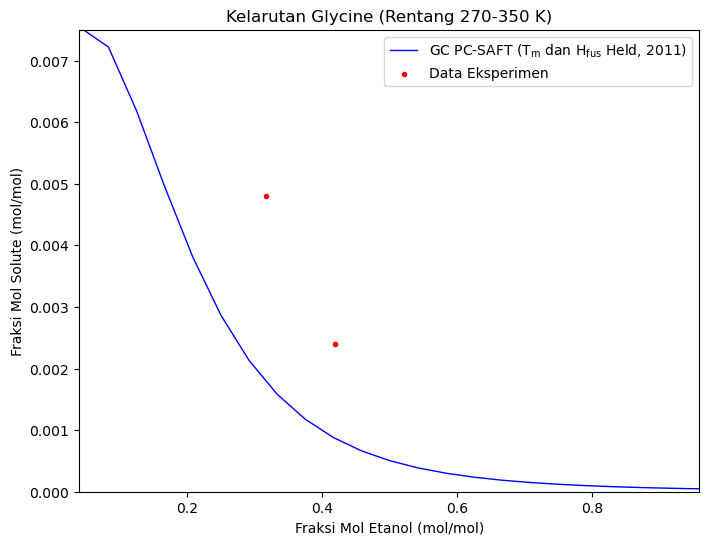

In [35]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine_air_etanol.csv", DataFrame)

function plot_T(df)
    T = 298.15
    p = 101325
    x_ethanol = LinRange(0.,1.,25)
    
    s = zeros(length(x_ethanol))
    
    for i in 1:length(x_ethanol)
        s[i] = sle_solubility(model3, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_held"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Ethanol = x_ethanol,
        Fraksi_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_ethanol, s, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.x_ethanol, df.out_s, label = "Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.04, 0.958)
    plt.ylim(0.0, 0.0075)
    
    plt.legend(loc="upper right")
    plt.savefig("3_plot_T_glycine_air_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)

In [30]:
aard_p   = calculate_AAD(model3, "sol_glycine_air_etanol.csv", solubility_held)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.007450      78.9545 
0.1168      0.015900      0.006417      59.6442 
0.1706      0.011300      0.004836      57.2070 
0.3164      0.004800      0.001784      62.8331 
0.4186      0.002400      0.000867      63.8784 
AARD = 64.5034%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


64.50342531191461

# 4
- pure comp: GC
- kij: molecular
- melting: GC

In [36]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter4 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
ethanol,46.07,2.3827,3.1771,198.24,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter4 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_gclow,0.054
ethanol,glycine_gcmid,0.054
ethanol,glycine_gcup,0.054
water,glycine_gclow,-0.0612
water,glycine_gcmid,-0.0612
water,glycine_gcup,-0.0612
water,ethanol,-0.0382
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter4 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
ethanol,H,glycine_gclow,e,2832.759,0.088581
ethanol,e,glycine_gclow,H,2832.759,0.088581
ethanol,H,glycine_gcmid,e,2832.759,0.088581
ethanol,e,glycine_gcmid,H,2832.759,0.088581
ethanol,H,glycine_gcup,e,2832.759,0.088581
ethanol,e,glycine_gcup,H,2832.759,0.088581
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
water,e,ethanol,H,2539.535,0.037949
water,H,ethanol,e,2539.535,0.037949
"""
components_low = ["water", "ethanol", "glycine_gclow"]
components_mid = ["water", "ethanol", "glycine_gcmid"]
components_up = ["water", "ethanol", "glycine_gcup"]

model4_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])


println("low bound")
println("Hfus = ", model4_low.solid.params.Hfus[2])
println("Tm = ", model4_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model4_mid.solid.params.Hfus[2])
println("Tm = ", model4_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model4_up.solid.params.Hfus[2])
println("Tm = ", model4_up.solid.params.Tm[2])

low bound
Hfus = 4969.0
Tm = 158.7
mid bound
Hfus = 4969.0
Tm = 158.7
up bound
Hfus = 4969.0
Tm = 158.7



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Fraksi_Ethanol  Fraksi_Solute_Low  Fraksi_Solute_Mid  Fraksi_Solute_Up 
     │ Float64         Float64            Float64            Float64          
─────┼────────────────────────────────────────────────────────────────────────
   1 │      0.0            NaN                NaN               NaN
   2 │      0.0416667        0.188484           0.0715267         0.0172672
   3 │      0.0833333        0.157286           0.0484744         0.0114458
   4 │      0.125            0.122098           0.0319416         0.00771725
   5 │      0.166667         0.0871186          0.0212571         0.00529616
   6 │      0.208333         0.0586593          0.0144728         0.00369817
   7 │      0.25             0.0392434          0.0100895         0.00262603
   8 │      0.291667         0.0268616          0.00718709        0.00189511
   9 │      0.333333         0.0189149          0.00521946        0.00138899
  10 │      0.375            0.01

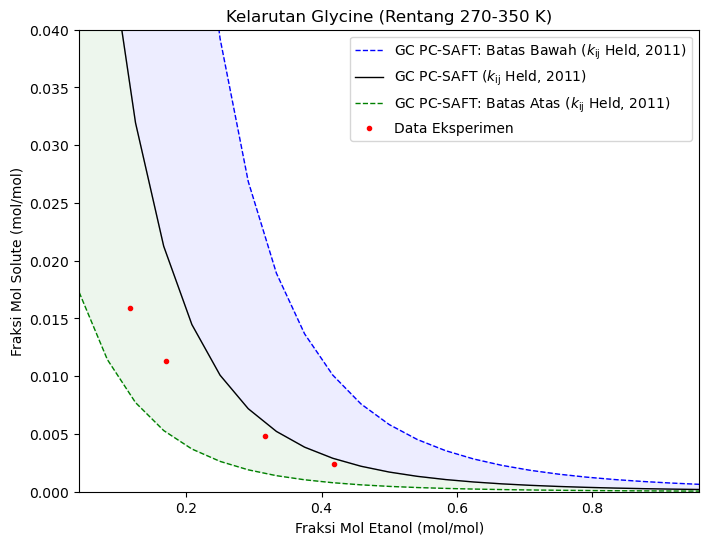

In [43]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine_air_etanol.csv", DataFrame)

function plot_T(df)
    T = 298.15
    p = 101325
    x_ethanol = LinRange(0.,1.,25)
    
    s_low = zeros(length(x_ethanol))
    s_mid = zeros(length(x_ethanol))
    s_up = zeros(length(x_ethanol))

    
    for i in 1:length(x_ethanol)
        s_low[i] = sle_solubility(model4_low, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gclow"])[3]
        s_mid[i] = sle_solubility(model4_mid, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gcmid"])[3]
        s_up[i]  = sle_solubility(model4_up, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gcup"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Ethanol = x_ethanol,
        Fraksi_Solute_Low = s_low,
        Fraksi_Solute_Mid = s_mid,
        Fraksi_Solute_Up = s_up,)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_ethanol, s_low, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(x_ethanol, s_mid, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(x_ethanol, s_up, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_between(x_ethanol, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_between(x_ethanol, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.x_ethanol, df.out_s, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.0416667, 0.958333)
    plt.ylim(0.0, 0.04)
    
    plt.legend(loc="upper right")
    plt.savefig("4_plot_T_glycine_air_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)

In [44]:
aard_p   = calculate_AAD(model4_low, "sol_glycine_air_etanol.csv", solubility_gclow)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.194231      448.6763
0.1168      0.015900      0.129185      712.4820
0.1706      0.011300      0.084045      643.7567
0.3164      0.004800      0.021733      352.7771
0.4186      0.002400      0.009957      314.8588
AARD = 494.5102%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


494.51018375496585

In [45]:
aard_p   = calculate_AAD(model4_mid, "sol_glycine_air_etanol.csv", solubility_gcmid)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.076824      117.0182
0.1168      0.015900      0.034671      118.0570
0.1706      0.011300      0.020473      81.1726 
0.3164      0.004800      0.005929      23.5254 
0.4186      0.002400      0.002858      19.0836 
AARD = 71.7714%


71.77137338294419

In [46]:
aard_p   = calculate_AAD(model4_up, "sol_glycine_air_etanol.csv", solubility_gcup)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.018815      46.8507 
0.1168      0.015900      0.008327      47.6273 
0.1706      0.011300      0.005115      54.7389 
0.3164      0.004800      0.001573      67.2378 
0.4186      0.002400      0.000769      67.9437 
AARD = 56.8797%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


56.879680743843906

# 5
- pure comp: GC
- kij: 0
- melting: GC

In [47]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter5 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
ethanol,46.07,2.3827,3.1771,198.24,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter5 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_gclow,0
ethanol,glycine_gcmid,0
ethanol,glycine_gcup,0
water,glycine_gclow,0
water,glycine_gcmid,0
water,glycine_gcup,0
water,ethanol,0
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter5 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
ethanol,H,glycine_gclow,e,2832.759,0.088581
ethanol,e,glycine_gclow,H,2832.759,0.088581
ethanol,H,glycine_gcmid,e,2832.759,0.088581
ethanol,e,glycine_gcmid,H,2832.759,0.088581
ethanol,H,glycine_gcup,e,2832.759,0.088581
ethanol,e,glycine_gcup,H,2832.759,0.088581
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
water,e,ethanol,H,2539.535,0.037949
water,H,ethanol,e,2539.535,0.037949
"""
components_low = ["water", "ethanol", "glycine_gclow"]
components_mid = ["water", "ethanol", "glycine_gcmid"]
components_up = ["water", "ethanol", "glycine_gcup"]

model5_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])


println("low bound")
println("Hfus = ", model5_low.solid.params.Hfus[2])
println("Tm = ", model5_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model5_mid.solid.params.Hfus[2])
println("Tm = ", model5_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model5_up.solid.params.Hfus[2])
println("Tm = ", model5_up.solid.params.Tm[2])

low bound
Hfus = 4969.0
Tm = 158.7
mid bound
Hfus = 4969.0
Tm = 158.7
up bound
Hfus = 4969.0
Tm = 158.7



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Fraksi_Ethanol  Fraksi_Solute_Low  Fraksi_Solute_Mid  Fraksi_Solute_Up 
     │ Float64         Float64            Float64            Float64          
─────┼────────────────────────────────────────────────────────────────────────
   1 │      0.0             NaN               NaN               NaN
   2 │      0.0416667         0.0401113         0.00834358        0.0020714
   3 │      0.0833333         0.0398912         0.00893232        0.00224811
   4 │      0.125             0.037198          0.00884951        0.00225928
   5 │      0.166667          0.0334056         0.00833132        0.0021538
   6 │      0.208333          0.0293109         0.00758147        0.00198013
   7 │      0.25              0.0253471         0.00674419        0.00177585
   8 │      0.291667          0.0217254         0.00590984        0.00156617
   9 │      0.333333          0.018528          0.0051289         0.00136614
  10 │      0.375             0.0

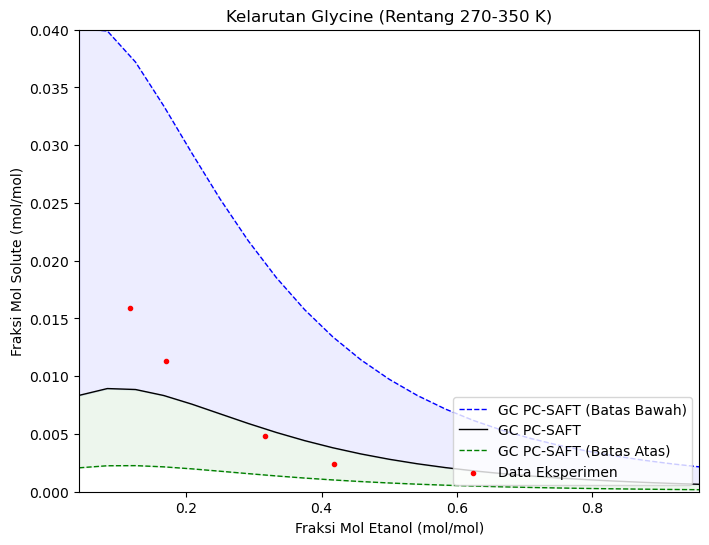

In [48]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_air_etanol.csv", DataFrame)

function plot_T(df)
    T = 298.15
    p = 101325
    x_ethanol = LinRange(0.,1.,25)
    
    s_low = zeros(length(x_ethanol))
    s_mid = zeros(length(x_ethanol))
    s_up = zeros(length(x_ethanol))

    
    for i in 1:length(x_ethanol)
        s_low[i] = sle_solubility(model5_low, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gclow"])[3]
        s_mid[i] = sle_solubility(model5_mid, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gcmid"])[3]
        s_up[i]  = sle_solubility(model5_up, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gcup"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Ethanol = x_ethanol,
        Fraksi_Solute_Low = s_low,
        Fraksi_Solute_Mid = s_mid,
        Fraksi_Solute_Up = s_up,)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_ethanol, s_low, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(x_ethanol, s_mid, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(x_ethanol, s_up, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_between(x_ethanol, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_between(x_ethanol, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.x_ethanol, df.out_s, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.0416667, 0.958333)
    plt.ylim(0.0, 0.04)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_T_glycine_air_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)

In [49]:
aard_p   = calculate_AAD(model5_low, "sol_glycine_air_etanol.csv", solubility_gclow)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.039671      12.0638 
0.1168      0.015900      0.037848      138.0360
0.1706      0.011300      0.033020      192.2133
0.3164      0.004800      0.019771      311.9057
0.4186      0.002400      0.013306      454.4354
AARD = 221.7308%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


221.73083561543604

In [50]:
aard_p   = calculate_AAD(model5_mid, "sol_glycine_air_etanol.csv", solubility_gcmid)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.008122      77.0554 
0.1168      0.015900      0.008907      43.9780 
0.1706      0.011300      0.008267      26.8385 
0.3164      0.004800      0.005437      13.2728 
0.4186      0.002400      0.003779      57.4709 
AARD = 43.7231%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


43.72311352531479

In [51]:
aard_p   = calculate_AAD(model5_up, "sol_glycine_air_etanol.csv", solubility_gcup)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.002012      94.3167 
0.1168      0.015900      0.002268      85.7363 
0.1706      0.011300      0.002140      81.0661 
0.3164      0.004800      0.001445      69.8864 
0.4186      0.002400      0.001014      57.7411 
AARD = 77.7493%


77.74931646330074

# 6
- pure comp: GC
- kij: molecular (VLE GC)
- melting: GC

In [52]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter6 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
ethanol,46.07,2.3827,3.1771,198.24,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter6 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
ethanol,glycine_gclow,0.114928718
ethanol,glycine_gcmid,0.114928718
ethanol,glycine_gcup,0.114928718
water,glycine_gclow,0.000013527940174729
water,glycine_gcmid,0.000013527940174729
water,glycine_gcup,0.000013527940174729
water,ethanol,0.056321984
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter6 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
ethanol,H,ethanol,e,2653.4,0.032384
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
ethanol,H,glycine_gclow,e,2832.759,0.088581
ethanol,e,glycine_gclow,H,2832.759,0.088581
ethanol,H,glycine_gcmid,e,2832.759,0.088581
ethanol,e,glycine_gcmid,H,2832.759,0.088581
ethanol,H,glycine_gcup,e,2832.759,0.088581
ethanol,e,glycine_gcup,H,2832.759,0.088581
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
water,e,ethanol,H,2539.535,0.037949
water,H,ethanol,e,2539.535,0.037949
"""
components_low = ["water", "ethanol", "glycine_gclow"]
components_mid = ["water", "ethanol", "glycine_gcmid"]
components_up = ["water", "ethanol", "glycine_gcup"]

model6_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])


println("low bound")
println("Hfus = ", model6_low.solid.params.Hfus[2])
println("Tm = ", model6_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model6_mid.solid.params.Hfus[2])
println("Tm = ", model6_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model6_up.solid.params.Hfus[2])
println("Tm = ", model6_up.solid.params.Tm[2])

low bound
Hfus = 4969.0
Tm = 158.7
mid bound
Hfus = 4969.0
Tm = 158.7
up bound
Hfus = 4969.0
Tm = 158.7



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Fraksi_Ethanol  Fraksi_Solute_Low  Fraksi_Solute_Mid  Fraksi_Solute_Up 
     │ Float64         Float64            Float64            Float64          
─────┼────────────────────────────────────────────────────────────────────────
   1 │      0.0            NaN                NaN               NaN
   2 │      0.0416667        0.0305359          0.00672333        0.00169411
   3 │      0.0833333        0.0240833          0.00583277        0.00150121
   4 │      0.125            0.0182832          0.00473379        0.00123881
   5 │      0.166667         0.0136344          0.00369565        0.000978981
   6 │      0.208333         0.0100962          0.00282374        0.000754525
   7 │      0.25             0.00747149         0.00213518        0.00057405
   8 │      0.291667         0.00554838         0.00160953        0.000434615
   9 │      0.333333         0.00414585         0.0012154         0.000329214
  10 │      0.375          

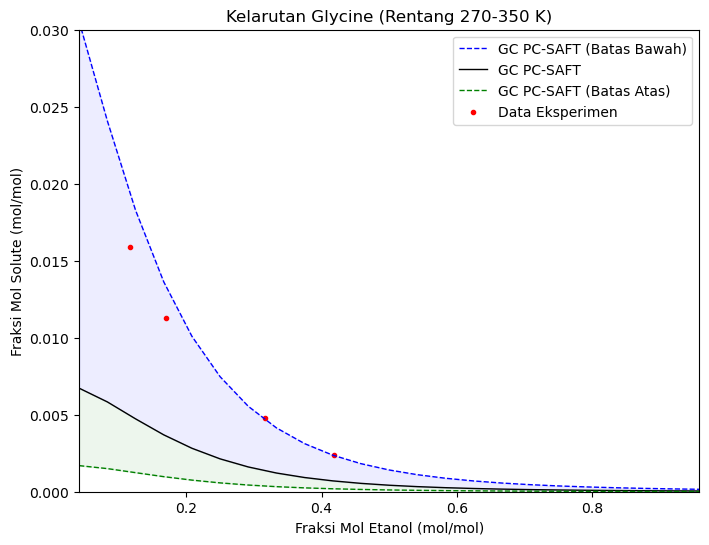

In [57]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_air_etanol.csv", DataFrame)

function plot_T(df)
    T = 298.15
    p = 101325
    x_ethanol = LinRange(0.,1.,25)
    
    s_low = zeros(length(x_ethanol))
    s_mid = zeros(length(x_ethanol))
    s_up = zeros(length(x_ethanol))

    
    for i in 1:length(x_ethanol)
        s_low[i] = sle_solubility(model6_low, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gclow"])[3]
        s_mid[i] = sle_solubility(model6_mid, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gcmid"])[3]
        s_up[i]  = sle_solubility(model6_up, p, T, [1-x_ethanol[i],x_ethanol[i],0.]; solute=["glycine_gcup"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Ethanol = x_ethanol,
        Fraksi_Solute_Low = s_low,
        Fraksi_Solute_Mid = s_mid,
        Fraksi_Solute_Up = s_up,)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_ethanol, s_low, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(x_ethanol, s_mid, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(x_ethanol, s_up, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_between(x_ethanol, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_between(x_ethanol, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.x_ethanol, df.out_s, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.0416667, 0.958333)
    plt.ylim(0.0, 0.03)
    
    plt.legend(loc="upper right")
    plt.savefig("6_plot_T_glycine_air_etanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)

In [58]:
aard_p   = calculate_AAD(model6_low, "sol_glycine_air_etanol.csv", solubility_gclow)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.031802      10.1652 
0.1168      0.015900      0.019337      21.6147 
0.1706      0.011300      0.013253      17.2802 
0.3164      0.004800      0.004662      2.8818  
0.4186      0.002400      0.002343      2.3594  
AARD = 10.8603%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


10.860262393298605

In [59]:
aard_p   = calculate_AAD(model6_mid, "sol_glycine_air_etanol.csv", solubility_gcmid)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.006839      80.6804 
0.1168      0.015900      0.004951      68.8640 
0.1706      0.011300      0.003605      68.0988 
0.3164      0.004800      0.001361      71.6378 
0.4186      0.002400      0.000696      70.9976 
AARD = 72.0557%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


72.05572035274335

In [60]:
aard_p   = calculate_AAD(model6_up, "sol_glycine_air_etanol.csv", solubility_gcup)


=== AAD: sol_glycine_air_etanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0331      0.035400      0.001715      95.1548 
0.1168      0.015900      0.001292      91.8754 
0.1706      0.011300      0.000956      91.5412 
0.3164      0.004800      0.000368      92.3263 
0.4186      0.002400      0.000189      92.1131 
AARD = 92.6022%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


92.60216697448409